In [126]:
import pandas
import matplotlib.pyplot as plt
data = pandas.read_csv('prices_round_1_day_0.csv',sep=';')
squid_ink=data[data['product']=="SQUID_INK"]

In [127]:
def gradient(point1,point2):
    return (point2[1]-point1[1])/(point2[0]-point1[0])

In [128]:
a = list(squid_ink['timestamp'])
b = list(squid_ink['ask_price_1'])
#print(a[1])
#print(b[1])
gradient([a[3],b[3]],[a[1],b[1]])


-0.015

In [129]:
def gradientChange(point1,point2,point3) :
    return (gradient(point3,point1)-gradient(point2,point1))/(point3[0]-point1[0])

In [130]:
a = list(squid_ink['timestamp'])
b = list(squid_ink['ask_price_1'])
print(gradient([a[25],b[25]],[a[35],b[35]]))
print(gradient([a[25],b[25]],[a[45],b[45]]))

print(gradientChange([a[25],b[25]],[a[35],b[35]],[a[45],b[45]]))

-0.002
-0.0005
7.5e-07


In [131]:
def upOrDown() :
    a = list(squid_ink['timestamp'])
    b = list(squid_ink['ask_price_1'])
    i = 0
    grad = None
    while True :
        gradient([a[i+1],b[i+1]],[a[i],b[i]])


In [132]:
# points = {}
# for idx, row in squid_ink.iterrows():
#     points[row['timestamp']] = row['ask_price_1']

# print(points)


In [133]:
import pandas as pd

data = pd.read_csv('prices_round_1_day_0.csv',sep=';')
ink = data[data['product']=="SQUID_INK"]
change1 = [] # array containing increasing price points
change2 = [] # array containing decreasing price points
change = [] # array containing all price points, if increasing = 1, if stable = 0, if decreasing = -1
diffArray = []
for i in range(1,10000,1):
    curr = (ink.iloc[i]['ask_price_1'] + ink.iloc[i]['bid_price_1'])/2
    past = (ink.iloc[i-1]['ask_price_1'] + ink.iloc[i-1]['bid_price_1'])/2
    grad = (ink.iloc[i]['ask_price_1']-ink.iloc[i-1]['ask_price_1'])/(ink.iloc[i]['timestamp']-ink.iloc[i-1]['timestamp'])
    diff = (ink.iloc[i]['ask_price_1']-ink.iloc[i-1]['ask_price_1'])
    if grad < 0 :
        change2.append(1)
        change1.append(0)
        change.append(-1)
        diffArray.append(diff/2)
    elif grad > 0 :
        change1.append(1)
        change2.append(0)
        change.append(1)
        diffArray.append(diff/2)
    else :
        change1.append(0)
        change2.append(0)
        change.append(0)
        diffArray.append(0)

print(change)

positive=[]
for j in range(len(change1)) :
    positive.append(squid_ink.iloc[j]['ask_price_1']*change1[j]+diffArray[j])
positive.append(0)
#print(positive)

negative = []
for k in range(len(change2)) :
    negative.append(squid_ink.iloc[k]['ask_price_1']*change2[k]+diffArray[k])
negative.append(0)
#print(negative)





[0, -1, -1, 0, 1, -1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, -1, 1, -1, 1, -1, 1, 0, 1, 0, 0, -1, 1, 0, 0, -1, 1, 0, -1, 0, 0, -1, 1, 0, 0, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 0, 1, -1, 1, 0, 1, -1, 1, -1, 1, -1, 1, 1, 1, -1, -1, 0, 0, -1, 1, -1, 1, 0, 1, 1, 0, -1, 0, 1, 1, 0, 1, -1, 0, 1, 1, -1, -1, 1, 0, 0, 1, 1, -1, 1, -1, 1, -1, 1, -1, 1, 0, -1, 1, 0, 1, -1, 0, 1, -1, -1, 1, 0, -1, -1, 1, -1, 0, -1, 0, -1, 1, 1, -1, -1, 1, 1, -1, 0, 0, 0, 1, 1, 0, -1, 1, -1, 1, -1, 0, 1, 0, 1, -1, 1, -1, 0, 1, -1, -1, 0, -1, 1, -1, -1, 1, 0, 1, -1, -1, 1, 0, -1, -1, 1, 1, -1, 1, -1, 1, -1, 1, 1, 0, 1, -1, 1, -1, -1, -1, 1, 1, -1, 1, 0, 0, 1, 0, 1, -1, 1, 0, -1, 1, -1, 1, -1, 1, 1, -1, 1, 0, 0, 0, 1, 1, -1, 1, 1, -1, 1, -1, 1, 0, 1, -1, 1, 1, 0, -1, 0, 1, 0, -1, 1, 0, 0, -1, 1, 1, 0, 1, -1, 1, 0, 0, 0, -1, -1, 1, -1, -1, 1, -1, 1, 0, -1, 1, -1, 1, -1, -1, 0, 1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, 0, -1, 1, 0, 1, 1, 0, 1, -1, 1, 0, 1, -1, -1, 1, -1, 1, -1, 0, -1, 1, -1, -1, 0, 0, -1

In [134]:
trend = []
trendNeg = []
trendPos = []

period = 20

for i in list(range(0,len(change),period)) :
    upCounter = 0
    downCounter = 0
    for j in list(range(period)) :
        if change[i+j-1] > 0 :
            upCounter = upCounter + 1
        elif change[i+j-1] < 0 :
            downCounter = downCounter + 1
    if downCounter > upCounter :
        for k in list(range(period)) :
            trend.append(-1)
            trendNeg.append(1)
            trendPos.append(0)
    elif downCounter < upCounter : 
        for k in list(range(period)) :
            trend.append(1)
            trendNeg.append(0)
            trendPos.append(1)
    else :
        for k in list(range(period)) :
            if i != 0 :
                trend.append(trend[i-1])
                trendNeg.append(trendNeg[i-1])
                trendPos.append(trendPos[i-1])
            else :
                trend.append(0)
                trendNeg.append(0)
                trendPos.append(0)

print(trend)
print(trendPos)
print(trendNeg)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,

In [135]:
positiveTrend=[]
for j in range(len(change1)) :
    positiveTrend.append(squid_ink.iloc[j]['ask_price_1']*trendPos[j]+diffArray[j])
positiveTrend.append(0)
#print(positive)

negativeTrend = []
for k in range(len(change2)) :
    negativeTrend.append(squid_ink.iloc[k]['ask_price_1']*trendNeg[k]+diffArray[k])
negativeTrend.append(0)
#print(negative)


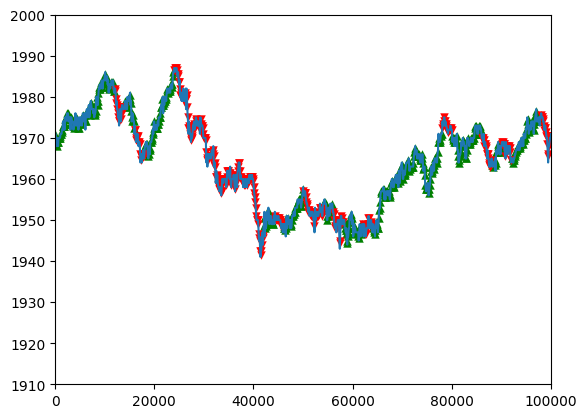

In [138]:

plt.plot(squid_ink['timestamp'],squid_ink['ask_price_1'])
plt.scatter(squid_ink['timestamp']+50,positiveTrend, color='g',marker='^',linewidths=0.05)
plt.scatter(squid_ink['timestamp']+50,negativeTrend, color='r',marker='v',linewidths=0.05)
ax = plt.gca()
ax.set_xlim([0, 100000])
ax.set_ylim([1910, 2000])
plt.show()